# 🧭 Customer Segmentation using Gaussian Mixture Model (GMM)

This project performs **clustering on customer data** using **Gaussian Mixture Models (GMM)**.  
It includes:

- ✅ Data preprocessing and standardization  
- 🧠 Dimensionality reduction with **PCA**  
- 📊 Optimal cluster selection using **Silhouette Score**  
- 🖼️ Visualization of clusters in 2D space  
- 📈 Computation of **cluster-wise averages** for better interpretation

This method helps in identifying meaningful customer segments such as:
- High-income & high-spending customers (premium segment)  
- High-income & low-spending customers (potential upsell segment)  
- Low-income & high-spending customers (budget-conscious segment)
ious segment)
ious segment)


## Import required libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


## Load and Inspect Data

In [13]:
file_path = 'CC.csv'  # TODO: Update with correct path if needed
df = pd.read_csv(file_path)

print(f" Dataset loaded with shape: {df.shape}")
print("\n Missing Values per Column:\n", df.isnull().sum())

 Dataset loaded with shape: (8950, 18)

 Missing Values per Column:
 CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


## Data Cleaning and Preprocessing

In [19]:
# Drop non-numeric ID column and fill missing values with column mean
if 'CUST_ID' in df.columns:
    df.drop('CUST_ID', axis=1, inplace=True)
df.fillna(df.mean(), inplace=True)

# Standardize features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

## Dimensionality Reduction (PCA)orm(df)

In [22]:
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)


## Determine Optimal Cluster Count using Silhouette Score

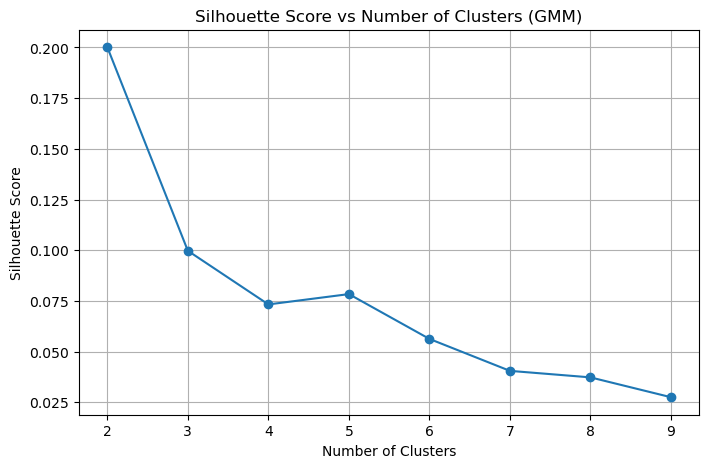

In [25]:
sil_scores = []
cluster_range = range(2, 10)

for n in cluster_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(df_scaled)
    labels = gmm.predict(df_scaled)
    sil = silhouette_score(df_scaled, labels)
    sil_scores.append(sil)

# 📊 Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters (GMM)')
plt.grid(True)
plt.show()

## Final GMM model

In [28]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(df_scaled)
labels = gmm.predict(df_scaled)

# Add cluster label to DataFrame
df['Cluster'] = labels


## Visualization of Clusters (PCA)

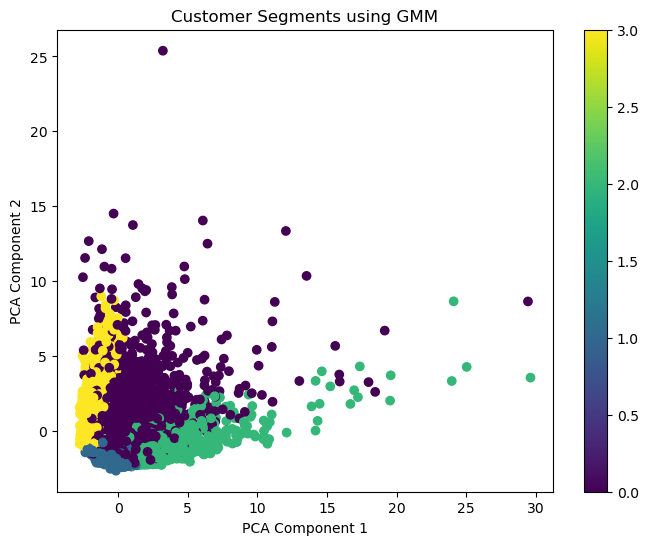

In [31]:
# Use PCA-reduced features
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=labels, cmap='viridis')
plt.title('Customer Segments using GMM')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar()
plt.show()


In [33]:
cluster_summary = df.groupby('Cluster').mean()
print("\n📊 Cluster Averages:\n", cluster_summary)


📊 Cluster Averages:
              BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        2643.504771           0.943941  1488.136095        905.308247   
1          47.293641           0.668885   385.791467         73.495586   
2        1177.570492           0.943127  2042.621699       1263.286256   
3        2045.374401           0.896427    59.162025         59.162025   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    582.930347   1939.425263             0.659565   
1                    312.640577      0.051589             0.601008   
2                    780.095825      0.130868             0.759159   
3                      0.000000   1757.911427             0.041998   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                

### Cluster Summary

The GMM model segmented the customers into **4 clusters** based on their credit card usage behavior:

- **Cluster 0**: High balance and high spending - likely premium customers.  
- **Cluster 1**: Low balance, moderate installment purchases - budget-conscious users.  
- **Cluster 2**: High purchases and transactions with high credit limits - valuable and active customers.  
- **Cluster 3**: High cash advance usage, low purchases - possibly high credit dependency.

These insights can support **targeted marketing**, **credit risk analysis**, and **personalized financial strategies**.
